In [ ]:
# ------------------------------------------------------
# Problem Definition
# This project analyzes the financial performance of major US airlines from 2021 to 2025
# after the COVID-19 pandemic. It aims to compare revenue recovery, net income, and
# profitability margins across carriers, and provide data-driven business insights.
#
# Intended users: Course instructors, students, and industry analysts.
# ------------------------------------------------------

In [1]:
# Import Libraries
import wrds
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------
# 1. Connect to WRDS
# ----------------------
db = wrds.Connection(wrds_username="your_wrds_username")
# Data Source: WRDS Compustat
# Data Access Date: 2026-04-20
# Fiscal Year: 2021 - 2025

WRDS recommends setting up a .pgpass file.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [2]:
# 2. Extract data from WRDS using SQL query
df = db.raw_sql('''
    SELECT tic, conm, datadate, fyear, revt, ni, pi
    FROM comp.funda
    WHERE tic IN ('AAL', 'DAL', 'LUV', 'UAL')
    AND fyear BETWEEN 2021 AND 2025
    AND revt IS NOT NULL
    AND ni IS NOT NULL
''')
db.close()

In [3]:
# 3. Data cleaning (strict and thorough)
# Filter for 2021-2025
df = df[(df['fyear'] >= 2021) & (df['fyear'] <= 2025)]

# Remove duplicate rows
df = df.drop_duplicates()

# Remove rows with missing key values
df = df.dropna(subset=['tic', 'fyear', 'revt', 'ni', 'pi'])

# Remove invalid revenue data
df = df[df['revt'] > 0]

# Remove extreme outliers for net income
df = df[(df['ni'] > -15000) & (df['ni'] < 15000)]

# Sort data and reset index
df = df.sort_values(by=['tic', 'fyear']).reset_index(drop=True)
# 4. Calculate financial ratios
df['net_profit_margin'] = (df['ni'] / df['revt'] * 100).round(2)
df['operating_profit_margin'] = (df['pi'] / df['revt'] * 100).round(2)

In [5]:
# 4. Calculate financial ratios
df['net_profit_margin'] = (df['ni'] / df['revt'] * 100).round(2)
df['operating_profit_margin'] = (df['pi'] / df['revt'] * 100).round(2)


In [6]:
# 5. Interactive company selection
user_input = input("Enter tickers separated by commas (e.g., AAL,DAL,LUV): ")
selected_tickers = [ticker.strip().upper() for ticker in user_input.split(',')]
df_selected = df[df['tic'].isin(selected_tickers)]


In [7]:
# 6. Generate summary statistics
summary = df_selected.groupby('tic').agg({
    'revt': ['mean', 'max', 'min'],
    'ni': ['mean', 'max', 'min'],
    'net_profit_margin': ['mean', 'max', 'min']
}).round(2)

print("\n" + "="*60)
print("      US Airlines Financial Performance Summary (2021-2025)")
print("="*60)
print(summary)



      US Airlines Financial Performance Summary (2021-2025)
        revt                        ni                 net_profit_margin  \
        mean      max      min    mean     max     min              mean   
tic                                                                        
AAL  48097.0  54633.0  29882.0   -17.4   846.0 -1993.0             -0.62   
DAL  52707.2  63364.0  29899.0  2933.8  5005.0   280.0               5.0   
LUV  24353.4  28063.0  15790.0   577.4   977.0   441.0              2.69   
UAL  47887.8  59070.0  24634.0  1578.6  3353.0 -1964.0              1.95   

                 
      max   min  
tic              
AAL  1.56 -6.67  
DAL  7.94  0.94  
LUV  6.19  1.57  
UAL  5.68 -7.97  


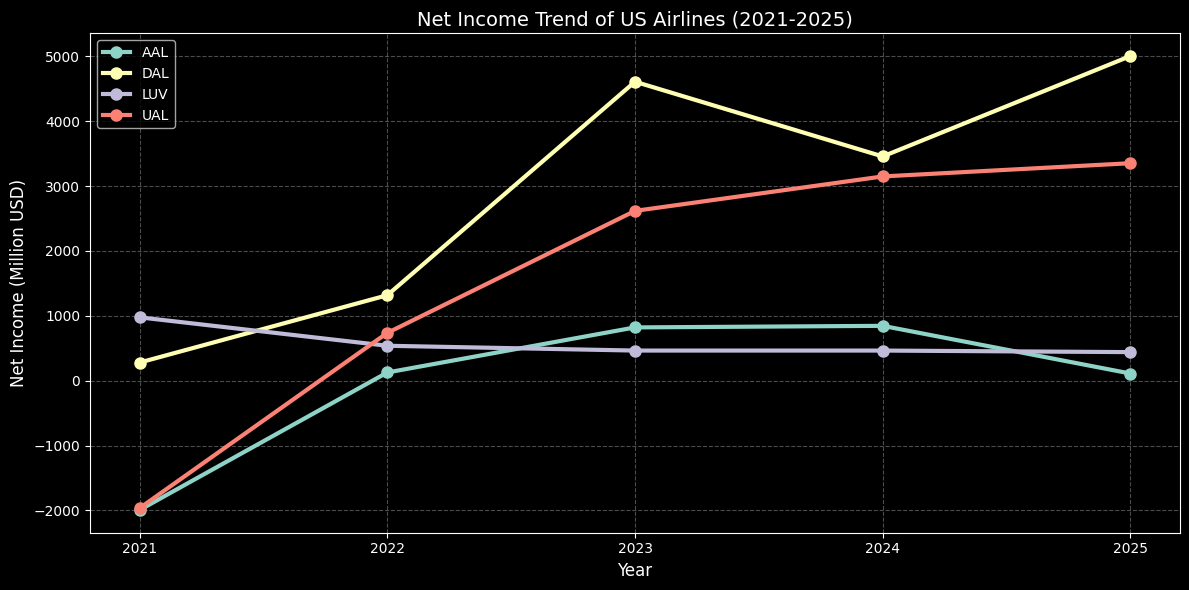

In [8]:
# 7. Figure 1:net income trend
# Visualize net income changes for four airlines over five years
plt.figure(figsize=(12, 6))

for tic in selected_tickers:
    company_data = df_selected[df_selected['tic'] == tic]
    plt.plot(company_data['fyear'], company_data['ni'],
             marker='o', linewidth=3, markersize=8, label=tic)

plt.title('Net Income Trend of US Airlines (2021-2025)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Net Income (Million USD)', fontsize=12)
plt.xticks(range(2021, 2026))
plt.legend()
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()

# Save plot
plt.savefig('airline_net_income_trend.png', dpi=300)
plt.show()


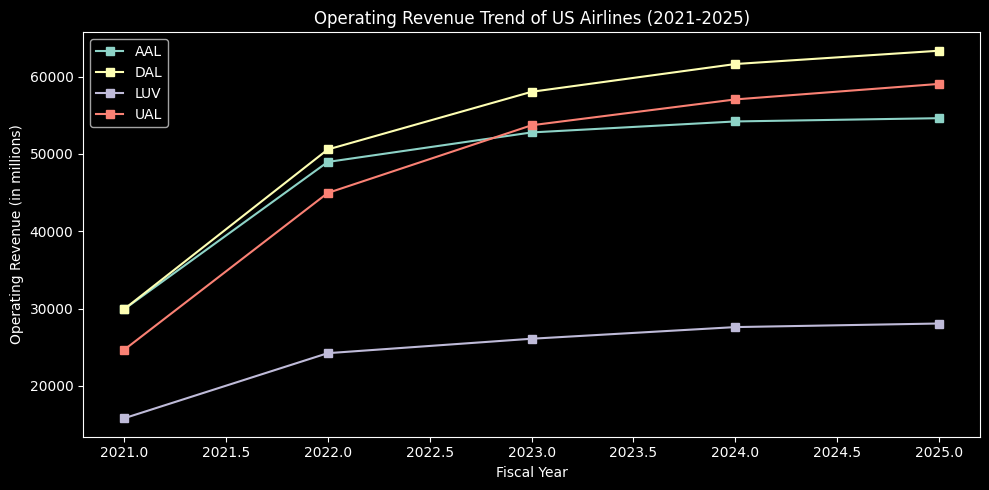

In [12]:
# Figure 2: Operating Revenue Trend (2021-2025)
# Show revenue recovery and scale differences among airlines
# ------------------------------
plt.figure(figsize=(10, 5))
for airline in ['AAL', 'DAL', 'LUV', 'UAL']:
    subset = df_selected[df_selected['tic'] == airline]
    plt.plot(subset['fyear'], subset['revt'], marker='s', label=airline)

plt.title('Operating Revenue Trend of US Airlines (2021-2025)')
plt.xlabel('Fiscal Year')
plt.ylabel('Operating Revenue (in millions)')
plt.legend()
plt.tight_layout()
plt.savefig('revenue_trend.png')


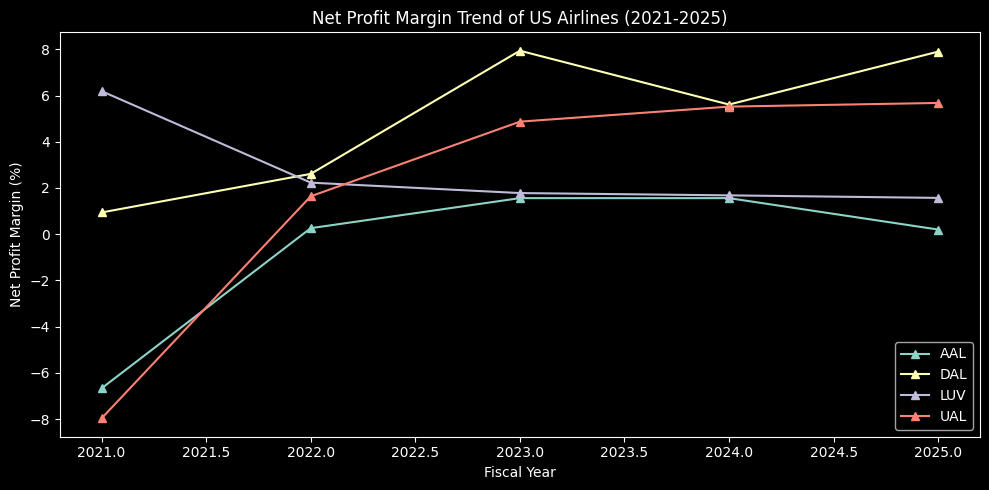

In [13]:
# Figure 3: Net Profit Margin Trend (2021-2025)
# Compare profitability efficiency across companies
# ------------------------------
plt.figure(figsize=(10, 5))
for airline in ['AAL', 'DAL', 'LUV', 'UAL']:
    subset = df_selected[df_selected['tic'] == airline]
    plt.plot(subset['fyear'], subset['net_profit_margin'], marker='^', label=airline)

plt.title('Net Profit Margin Trend of US Airlines (2021-2025)')
plt.xlabel('Fiscal Year')
plt.ylabel('Net Profit Margin (%)')
plt.legend()
plt.tight_layout()
plt.savefig('net_profit_margin_trend.png')

In [9]:
# 8. Export results to Excel
df_selected.to_excel('airlines_clean_data.xlsx', index=False)
summary.to_excel('airlines_analysis_summary.xlsx')

In [10]:
# 9. Completion message
print("\nAnalysis completed successfully!")
print("Files generated:")
print("- airline_net_income_trend.png")
print("- airlines_clean_data.xlsx")
print("- airlines_analysis_summary.xlsx")


Analysis completed successfully!
Files generated:
- airline_net_income_trend.png
- airlines_clean_data.xlsx
- airlines_analysis_summary.xlsx
